# TP IA ? Pr?diction des R?coltes au Burundi
Universit? Polytechnique de Gitega ? BAC 4 G?nie Logiciel


## Pr?paration de l'environnement

On importe les biblioth?ques n?cessaires et les fonctions r?utilisables du module `src/preprocess.py`. Le notebook reste limit? aux exercices 1 et 2 : exploration, nettoyage, encodage, normalisation et division train/test.


In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data" / "agriculture_burundi.csv").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

from src.preprocess import (
    load_data,
    report_missing,
    impute_missing,
    encode_categoricals,
    get_X_y,
    normalize_features,
    split_data,
    _continuous_numerical_columns,
)

DATA_PATH = PROJECT_ROOT / "data" / "agriculture_burundi.csv"
sns.set_theme(style="whitegrid", palette="Set2")
print('Initialisation termin?e.')


Initialisation termin?e.


## Exercice 1 ? Chargement, Exploration et Qualit? des Donn?es

Cette premi?re partie charge le fichier brut, v?rifie la structure du dataset, analyse les valeurs manquantes et produit les premi?res visualisations descriptives.


### Q1 ? Chargement des donn?es et dimensions

On charge le fichier CSV brut puis on inspecte le nombre de lignes, le nombre de colonnes, la p?riode couverte, les provinces et les cultures disponibles.


In [2]:
df = load_data(DATA_PATH)

print(f"Shape: {df.shape}")
print(f"P?riode couverte: {df['annee'].min()} - {df['annee'].max()}")
print(f"Nombre de provinces: {df['province'].nunique()}")
print("Provinces:", sorted(df['province'].dropna().unique()))
print(f"Nombre de cultures: {df['culture'].nunique()}")
print("Cultures:", sorted(df['culture'].dropna().unique()))
df.head()


Shape: (1620, 14)
P?riode couverte: 2015 - 2023
Nombre de provinces: 15
Provinces: ['Bubanza', 'Bujumbura Rural', 'Bururi', 'Cankuzo', 'Cibitoke', 'Gitega', 'Kayanza', 'Kirundo', 'Makamba', 'Muramvya', 'Muyinga', 'Mwaro', 'Ngozi', 'Rutana', 'Ruyigi']
Nombre de cultures: 6
Cultures: ['Bananier', 'Haricot', 'Manioc', 'Maïs', 'Patate douce', 'Sorgho']


,annee,saison,province,culture,altitude_m,pluviometrie_mm,temperature_moy_C,superficie_ha,utilisation_engrais,acces_irrigation,nb_menages,rendement_t_ha,production_totale_t,bonne_recolte
0,2015,A,Bujumbura Rural,Maïs,881,NaN,23.9,1.33,1.0,1,154,2.14,2.85,1.0
1,2015,A,Bujumbura Rural,Haricot,803,955.4,22.1,3.25,0.0,0,16,0.64,2.08,1.0
2,2015,A,Bujumbura Rural,Manioc,835,1060.3,24.9,1.71,1.0,1,103,13.38,22.88,1.0
3,2015,A,Bujumbura Rural,Patate douce,848,760.3,23.8,2.94,0.0,1,64,6.94,20.40,1.0
4,2015,A,Bujumbura Rural,Sorgho,837,1126.8,23.1,3.94,0.0,0,56,0.89,3.51,1.0


Le dataset contient **1 620 observations et 14 colonnes**. Il couvre la p?riode **2015 ? 2023**, soit 9 ann?es agricoles. Les donn?es repr?sentent **15 provinces** et **6 cultures** : bananier, haricot, manioc, ma?s, patate douce et sorgho. Cette structure correspond bien ? l'?nonc? : 9 ann?es ? 2 saisons ? 15 provinces ? 6 cultures = 1 620 lignes.


### Q2 ? Types des variables

On affiche les types de chaque colonne pour v?rifier leur coh?rence avec la description du dataset.


In [3]:
df.dtypes


annee                    int64
saison                     str
province                   str
culture                    str
altitude_m               int64
pluviometrie_mm        float64
temperature_moy_C      float64
superficie_ha          float64
utilisation_engrais    float64
acces_irrigation         int64
nb_menages               int64
rendement_t_ha         float64
production_totale_t    float64
bonne_recolte          float64
dtype: object

Les variables cat?gorielles (`saison`, `province`, `culture`) sont stock?es comme texte, ce qui est coh?rent. Les variables de mesure (`altitude_m`, `pluviometrie_mm`, `temperature_moy_C`, `superficie_ha`, `nb_menages`, `rendement_t_ha`, `production_totale_t`) sont num?riques. Les colonnes binaires (`utilisation_engrais`, `acces_irrigation`, `bonne_recolte`) sont num?riques 0/1 ; `utilisation_engrais` et `bonne_recolte` peuvent appara?tre en `float` ? cause des valeurs manquantes. Ce n'est pas une incoh?rence m?tier, mais cela devra ?tre nettoy? avant l'entra?nement.


### Q3 ? Valeurs manquantes

On calcule le nombre et le pourcentage de valeurs manquantes par colonne, puis on regarde leur r?partition par province et par culture.


In [4]:
missing_report = report_missing(df)
display(missing_report)

missing_by_province = df.isna().groupby(df['province']).mean() * 100
missing_by_culture = df.isna().groupby(df['culture']).mean() * 100

print("Valeurs manquantes par province (%):")
display(missing_by_province.loc[:, missing_report.index])

print("Valeurs manquantes par culture (%):")
display(missing_by_culture.loc[:, missing_report.index])


,missing_count,missing_percentage
pluviometrie_mm,63,3.888889
utilisation_engrais,45,2.777778
rendement_t_ha,44,2.716049
production_totale_t,44,2.716049
bonne_recolte,44,2.716049


Valeurs manquantes par province (%):


,pluviometrie_mm,utilisation_engrais,rendement_t_ha,production_totale_t,bonne_recolte
province,,,,,
Bubanza,3.703704,3.703704,3.703704,3.703704,3.703704
Bujumbura Rural,3.703704,2.777778,0.925926,0.925926,0.925926
Bururi,6.481481,2.777778,1.851852,1.851852,1.851852
Cankuzo,2.777778,1.851852,6.481481,6.481481,6.481481
Cibitoke,5.555556,0.925926,1.851852,1.851852,1.851852
Gitega,1.851852,2.777778,0.925926,0.925926,0.925926
Kayanza,1.851852,6.481481,2.777778,2.777778,2.777778
Kirundo,6.481481,1.851852,1.851852,1.851852,1.851852
Makamba,3.703704,2.777778,4.629630,4.629630,4.629630


Valeurs manquantes par culture (%):


,pluviometrie_mm,utilisation_engrais,rendement_t_ha,production_totale_t,bonne_recolte
culture,,,,,
Bananier,3.333333,3.703704,2.592593,2.592593,2.592593
Haricot,5.185185,2.592593,4.074074,4.074074,4.074074
Manioc,4.444444,1.111111,1.481481,1.481481,1.481481
Maïs,4.444444,3.333333,2.222222,2.222222,2.222222
Patate douce,2.962963,3.333333,3.703704,3.703704,3.703704
Sorgho,2.962963,2.592593,2.222222,2.222222,2.222222


Les valeurs manquantes concernent principalement `pluviometrie_mm`, `utilisation_engrais`, `rendement_t_ha`, `production_totale_t` et `bonne_recolte`. Le taux reste faible, mais il n'est pas totalement homog?ne entre provinces et cultures. C'est important agronomiquement : la pluie, le rendement et la production peuvent varier selon la localisation et la culture, donc une imputation globale unique serait moins pertinente.


### Q4 ? Traitement des valeurs manquantes

On applique la strat?gie centralis?e dans `impute_missing()` : suppression des lignes sans cible, imputation par m?diane de groupe pour les variables num?riques, et mode pour les variables binaires.


In [5]:
df_clean = impute_missing(df)

print(f"Shape avant nettoyage: {df.shape}")
print(f"Shape apr?s nettoyage: {df_clean.shape}")
print("Valeurs manquantes restantes:")
print(df_clean.isna().sum())


Shape avant nettoyage: (1620, 14)
Shape apr?s nettoyage: (1576, 14)
Valeurs manquantes restantes:
annee                  0
saison                 0
province               0
culture                0
altitude_m             0
pluviometrie_mm        0
temperature_moy_C      0
superficie_ha          0
utilisation_engrais    0
acces_irrigation       0
nb_menages             0
rendement_t_ha         0
production_totale_t    0
bonne_recolte          0
dtype: int64


La cible `bonne_recolte` n'est jamais imput?e, car cela reviendrait ? inventer des labels. Les variables num?riques sont imput?es par m?diane au niveau `(culture, province)`, ce qui respecte mieux les diff?rences agronomiques locales. Les variables binaires sont imput?es par le mode, car elles repr?sentent des choix 0/1. Apr?s nettoyage, il ne reste plus de valeurs manquantes.


### Q5 ? Statistiques descriptives

On r?sume les variables num?riques et on identifie la culture au rendement moyen le plus ?lev?/faible ainsi que la province la plus pluvieuse en moyenne.


In [6]:
numeric_summary = df_clean.select_dtypes(include='number').agg(['mean', 'median', 'std', 'min', 'max']).T
display(numeric_summary)

rendement_par_culture = df_clean.groupby('culture')['rendement_t_ha'].mean().sort_values(ascending=False)
pluie_par_province = df_clean.groupby('province')['pluviometrie_mm'].mean().sort_values(ascending=False)

print("Rendement moyen par culture:")
display(rendement_par_culture)
print("Culture au rendement moyen le plus ?lev?:", rendement_par_culture.index[0])
print("Culture au rendement moyen le plus faible:", rendement_par_culture.index[-1])
print("Province ? pluviom?trie moyenne la plus forte:", pluie_par_province.index[0])
display(pluie_par_province.head())


,mean,median,std,min,max
annee,2018.988579,2019.000,2.579750,2015.00,2023.00
altitude_m,1431.777919,1442.000,403.376157,730.00,2049.00
pluviometrie_mm,836.675952,827.500,139.347196,410.70,1303.60
temperature_moy_C,21.208693,21.100,1.580370,16.90,25.80
superficie_ha,2.393439,2.380,1.225076,0.30,4.50
utilisation_engrais,0.330584,0.000,0.470573,0.00,1.00
acces_irrigation,0.168147,0.000,0.374116,0.00,1.00
nb_menages,97.171320,98.000,47.870830,15.00,180.00
rendement_t_ha,4.512868,3.865,3.703192,0.47,16.57
production_totale_t,10.661345,5.090,11.314001,0.18,62.50


Rendement moyen par culture:


culture
Manioc          9.668571
Bananier        7.267795
Patate douce    6.679692
Maïs            1.484318
Sorgho          1.061818
Haricot         0.849846
Name: rendement_t_ha, dtype: float64

Culture au rendement moyen le plus ?lev?: Manioc
Culture au rendement moyen le plus faible: Haricot
Province ? pluviom?trie moyenne la plus forte: Mwaro


province
Mwaro       856.086321
Muramvya    855.000000
Bururi      852.038679
Kayanza     852.016190
Gitega      847.366355
Name: pluviometrie_mm, dtype: float64

Les statistiques descriptives donnent une premi?re lecture des ordres de grandeur : altitude, pluie, temp?rature, superficie et nombre de m?nages n'ont pas les m?mes ?chelles. La comparaison par culture met en ?vidence que le rendement moyen d?pend fortement du type de culture. La province avec la pluviom?trie moyenne la plus ?lev?e est un signal utile, car l'eau est un facteur important dans la r?ussite des r?coltes.


### Q6 ? Distribution de la variable cible

On mesure la proportion de bonnes et de mauvaises r?coltes apr?s suppression des lignes dont la cible ?tait manquante.


In [7]:
class_counts = df_clean['bonne_recolte'].value_counts().sort_index()
class_proportions = df_clean['bonne_recolte'].value_counts(normalize=True).sort_index() * 100

print("Effectifs par classe:")
display(class_counts)
print("Proportions par classe (%):")
display(class_proportions)


Effectifs par classe:


bonne_recolte
0.0     105
1.0    1471
Name: count, dtype: int64

Proportions par classe (%):


bonne_recolte
0.0     6.662437
1.0    93.337563
Name: proportion, dtype: float64

Le dataset est **d?s?quilibr?** : les bonnes r?coltes sont nettement plus fr?quentes que les mauvaises r?coltes. Cette situation peut pousser un mod?le ? pr?dire trop souvent la classe majoritaire. Pour l'entra?nement et l'?valuation, il faudra donc utiliser une division stratifi?e et regarder des m?triques comme le rappel, le F1-score et la matrice de confusion, pas seulement l'accuracy.


### Q7 ? Visualisations exploratoires

On produit quatre graphiques : rendement par culture, production annuelle, effet de l'engrais, et corr?lations entre variables num?riques.


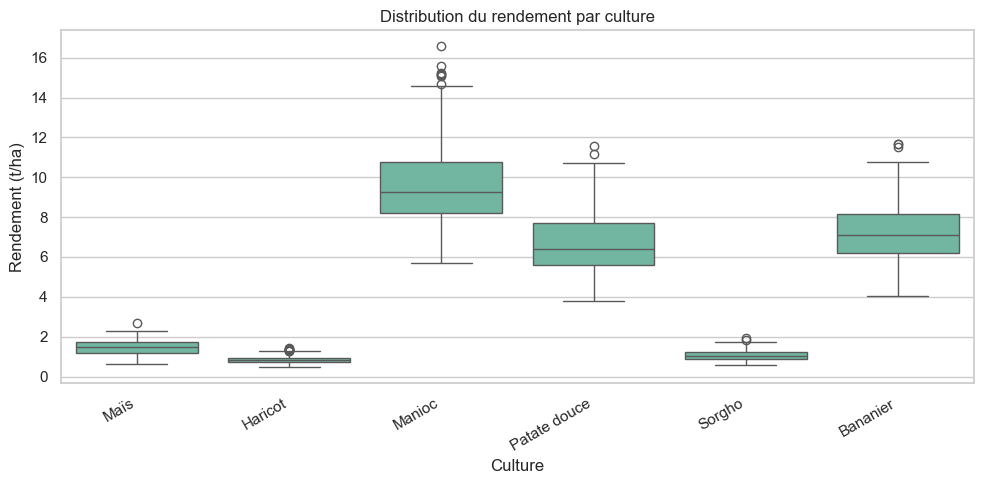

In [8]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_clean, x='culture', y='rendement_t_ha')
plt.title('Distribution du rendement par culture')
plt.xlabel('Culture')
plt.ylabel('Rendement (t/ha)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


Le boxplot montre que les rendements varient fortement selon la culture. Cette diff?rence est normale : chaque culture a un potentiel agronomique diff?rent et r?agit diff?remment ? la pluie, ? l'altitude et aux pratiques agricoles.


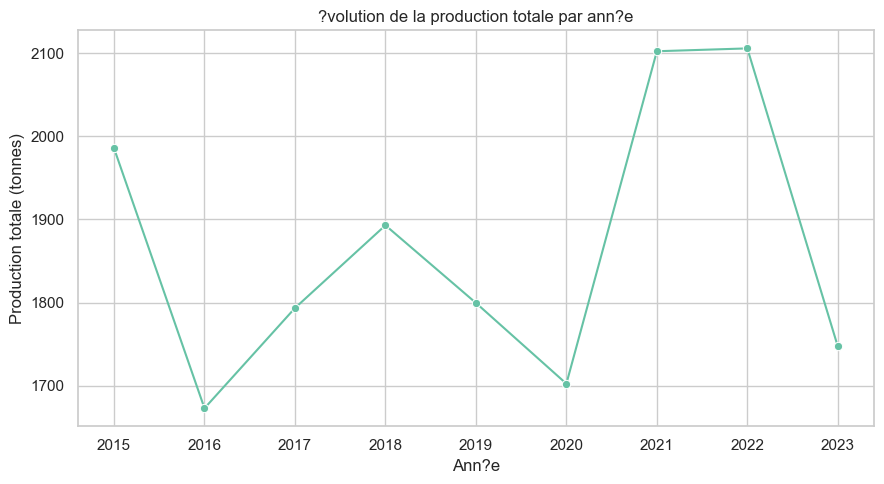

In [9]:
production_par_annee = df_clean.groupby('annee', as_index=False)['production_totale_t'].sum()

plt.figure(figsize=(9, 5))
sns.lineplot(data=production_par_annee, x='annee', y='production_totale_t', marker='o')
plt.title('?volution de la production totale par ann?e')
plt.xlabel('Ann?e')
plt.ylabel('Production totale (tonnes)')
plt.tight_layout()
plt.show()


La courbe annuelle permet de rep?rer les tendances globales et les ann?es atypiques. Une baisse peut correspondre ? des conditions climatiques d?favorables ou ? des rendements plus faibles sur plusieurs cultures.


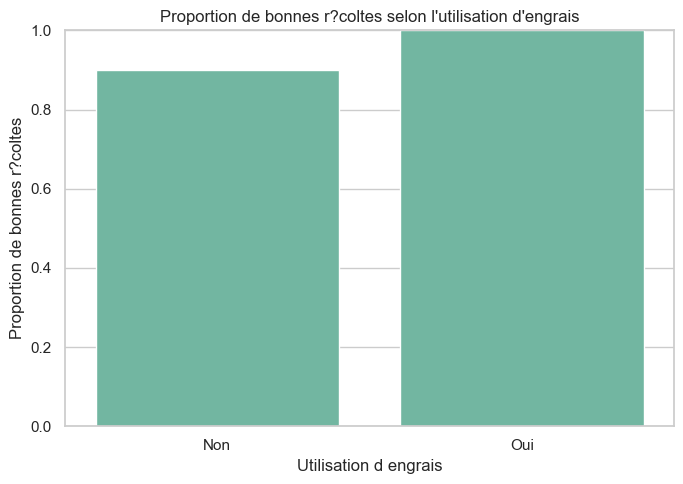

In [10]:
engrais_recolte = df_clean.groupby('utilisation_engrais', as_index=False)['bonne_recolte'].mean()
engrais_recolte['utilisation_engrais'] = engrais_recolte['utilisation_engrais'].map({0.0: 'Non', 1.0: 'Oui'})

plt.figure(figsize=(7, 5))
sns.barplot(data=engrais_recolte, x='utilisation_engrais', y='bonne_recolte')
plt.title("Proportion de bonnes r?coltes selon l'utilisation d'engrais")
plt.xlabel('Utilisation d engrais')
plt.ylabel('Proportion de bonnes r?coltes')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


Le barplot compare directement les parcelles avec et sans engrais. Si la proportion de bonnes r?coltes est plus ?lev?e avec engrais, cela soutient l'id?e que la fertilisation contribue ? am?liorer les r?sultats agricoles, m?me si cette relation devra ?tre confirm?e par les mod?les.


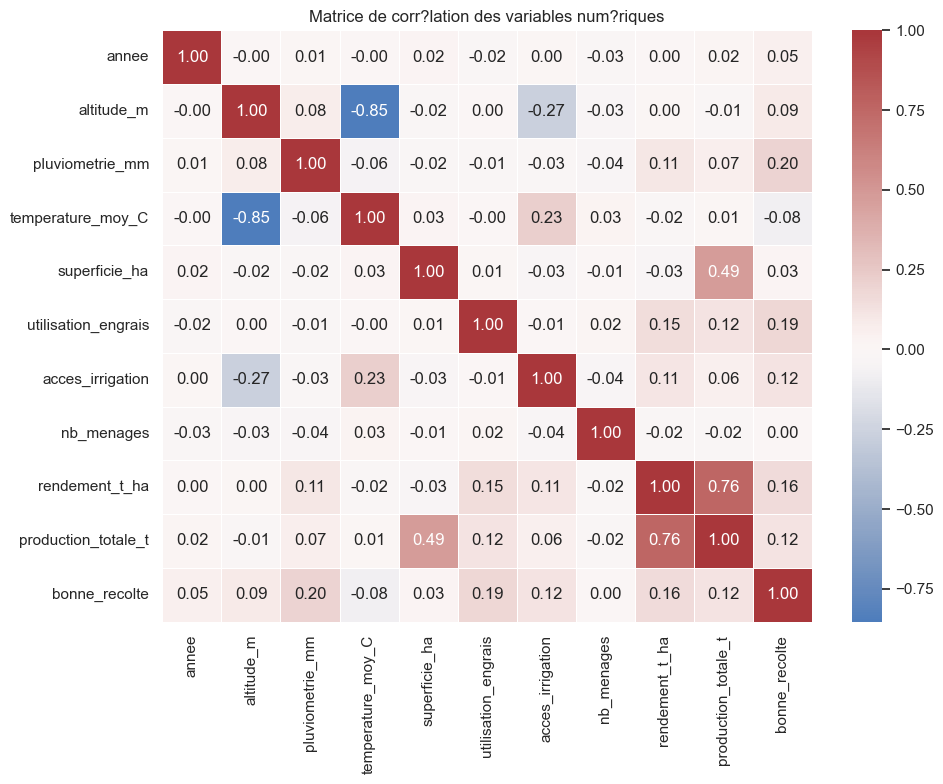

In [11]:
plt.figure(figsize=(10, 8))
corr = df_clean.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='vlag', center=0, linewidths=0.5)
plt.title('Matrice de corr?lation des variables num?riques')
plt.tight_layout()
plt.show()


La matrice de corr?lation met en ?vidence les relations lin?aires entre variables num?riques. `rendement_t_ha`, `production_totale_t` et `bonne_recolte` sont particuli?rement sensibles pour la mod?lisation, car le rendement et la production sont directement li?s ? la d?finition de la cible : les garder comme features provoquerait une fuite de donn?es.


## Exercice 2 ? Pr?traitement et Pr?paration des Donn?es

Cette deuxi?me partie transforme les donn?es propres en matrices compatibles avec les algorithmes de Machine Learning : encodage, s?paration X/y, normalisation et split train/test.


### Q8 ? Variables cat?gorielles et choix d'encodage

On identifie les variables cat?gorielles, puis on compare rapidement `LabelEncoder` et le One-Hot Encoding.


In [12]:
categorical_cols = df_clean.select_dtypes(include=['object', 'string']).columns.tolist()
print("Variables cat?gorielles:", categorical_cols)

label_demo = df_clean[['province', 'culture', 'saison']].copy()
for col in categorical_cols:
    label_demo[col + '_label'] = LabelEncoder().fit_transform(label_demo[col])

one_hot_demo = pd.get_dummies(df_clean[categorical_cols], drop_first=True)

print("Exemple LabelEncoder:")
display(label_demo.head())
print("Exemple One-Hot Encoding:")
display(one_hot_demo.head())
print(f"Nombre de colonnes One-Hot avec drop_first=True: {one_hot_demo.shape[1]}")


Variables cat?gorielles: ['saison', 'province', 'culture']
Exemple LabelEncoder:


,province,culture,saison,saison_label,province_label,culture_label
0,Bujumbura Rural,Maïs,A,0,1,3
1,Bujumbura Rural,Haricot,A,0,1,1
2,Bujumbura Rural,Manioc,A,0,1,2
3,Bujumbura Rural,Patate douce,A,0,1,4
4,Bujumbura Rural,Sorgho,A,0,1,5


Exemple One-Hot Encoding:


,saison_B,province_Bujumbura Rural,province_Bururi,province_Cankuzo,province_Cibitoke,province_Gitega,province_Kayanza,province_Kirundo,province_Makamba,province_Muramvya,province_Muyinga,province_Mwaro,province_Ngozi,province_Rutana,province_Ruyigi,culture_Haricot,culture_Manioc,culture_Maïs,culture_Patate douce,culture_Sorgho
0,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
1,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
2,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
3,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
4,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True


Nombre de colonnes One-Hot avec drop_first=True: 20


Les variables cat?gorielles sont `saison`, `province` et `culture`. On ne peut pas les utiliser directement dans la plupart des mod?les scikit-learn, car les algorithmes attendent des valeurs num?riques. `LabelEncoder` remplace chaque cat?gorie par un entier, mais cela cr?e un ordre artificiel entre les provinces ou les cultures. Le One-Hot Encoding cr?e une colonne binaire par modalit?, ce qui est plus adapt? ici pour `province`, `culture` et `saison`. Avec `drop_first=True`, on ?vite aussi la dummy variable trap, surtout utile pour la r?gression logistique.


### Q9 ? Encodage des variables cat?gorielles

On applique l'encodage choisi avec la fonction `encode_categoricals()` et on conserve la liste finale des colonnes de features pour garantir la coh?rence en inf?rence.


In [13]:
df_encoded, feature_columns = encode_categoricals(df_clean)

print(f"Nombre de colonnes avant encodage: {df_clean.shape[1]}")
print(f"Nombre de colonnes apr?s encodage: {df_encoded.shape[1]}")
print(f"Nombre de colonnes de features: {len(feature_columns)}")
print("Colonnes encod?es:")
print(df_encoded.columns.tolist())


Nombre de colonnes avant encodage: 14
Nombre de colonnes apr?s encodage: 31
Nombre de colonnes de features: 28
Colonnes encod?es:
['annee', 'altitude_m', 'pluviometrie_mm', 'temperature_moy_C', 'superficie_ha', 'utilisation_engrais', 'acces_irrigation', 'nb_menages', 'rendement_t_ha', 'production_totale_t', 'bonne_recolte', 'province_Bujumbura Rural', 'province_Bururi', 'province_Cankuzo', 'province_Cibitoke', 'province_Gitega', 'province_Kayanza', 'province_Kirundo', 'province_Makamba', 'province_Muramvya', 'province_Muyinga', 'province_Mwaro', 'province_Ngozi', 'province_Rutana', 'province_Ruyigi', 'culture_Haricot', 'culture_Manioc', 'culture_Maïs', 'culture_Patate douce', 'culture_Sorgho', 'saison_B']


Apr?s encodage, les cat?gories sont repr?sent?es par des indicateurs binaires. La liste `feature_columns` est importante pour la suite du projet : elle permettra de forcer exactement le m?me ordre et les m?mes colonnes lors des pr?dictions dans le notebook final et dans l'application Streamlit.


### Q10 ? D?finition de X et y

On s?pare les variables explicatives et la cible en excluant les colonnes qui provoqueraient une fuite de donn?es.


In [14]:
X, y = get_X_y(df_encoded)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print("Colonnes exclues de X: rendement_t_ha, production_totale_t, bonne_recolte")
display(X.head())
display(y.head())


X shape: (1576, 28)
y shape: (1576,)
Colonnes exclues de X: rendement_t_ha, production_totale_t, bonne_recolte


,annee,altitude_m,pluviometrie_mm,temperature_moy_C,superficie_ha,utilisation_engrais,acces_irrigation,nb_menages,province_Bujumbura Rural,province_Bururi,...,province_Mwaro,province_Ngozi,province_Rutana,province_Ruyigi,culture_Haricot,culture_Manioc,culture_Maïs,culture_Patate douce,culture_Sorgho,saison_B
0,2015,881,829.9,23.9,1.33,1.0,1,154,True,False,...,False,False,False,False,False,False,True,False,False,False
1,2015,803,955.4,22.1,3.25,0.0,0,16,True,False,...,False,False,False,False,True,False,False,False,False,False
2,2015,835,1060.3,24.9,1.71,1.0,1,103,True,False,...,False,False,False,False,False,True,False,False,False,False
3,2015,848,760.3,23.8,2.94,0.0,1,64,True,False,...,False,False,False,False,False,False,False,True,False,False
4,2015,837,1126.8,23.1,3.94,0.0,0,56,True,False,...,False,False,False,False,False,False,False,False,True,False


0    1.0
1    1.0
2    1.0
3    1.0
4    1.0
Name: bonne_recolte, dtype: float64

La cible est `bonne_recolte`. Les colonnes `rendement_t_ha` et `production_totale_t` sont exclues, car elles sont directement li?es ? la d?finition de la bonne r?colte. Les inclure donnerait au mod?le une information disponible apr?s la r?colte, ce qui cr?erait du data leakage et produirait des scores artificiellement ?lev?s.


### Q11 ? Normalisation des variables num?riques

On s?pare d'abord train/test, puis on applique le `StandardScaler` uniquement aux variables num?riques continues. Les colonnes binaires et One-Hot restent en 0/1.


In [15]:
X_train, X_test, y_train, y_test = split_data(X, y, test_size=0.2, random_state=42)
X_train_scaled, X_test_scaled, scaler = normalize_features(X_train, X_test)

continuous_cols = _continuous_numerical_columns(X_train)
print("Colonnes num?riques normalis?es:", continuous_cols)

scaled_stats = pd.DataFrame({
    'mean_after_scaling': X_train_scaled[continuous_cols].mean(),
    'std_after_scaling': X_train_scaled[continuous_cols].std(ddof=0),
})
display(scaled_stats)


Colonnes num?riques normalis?es: ['annee', 'altitude_m', 'pluviometrie_mm', 'temperature_moy_C', 'superficie_ha', 'nb_menages']


,mean_after_scaling,std_after_scaling
annee,-1.153222e-14,1.0
altitude_m,8.740803e-17,1.0
pluviometrie_mm,-7.655252e-16,1.0
temperature_moy_C,6.231347e-16,1.0
superficie_ha,-3.355341e-16,1.0
nb_menages,6.203151e-17,1.0


La normalisation est essentielle pour la r?gression logistique, car les coefficients et l'optimisation sont sensibles aux ?chelles des variables. Elle est moins critique pour les arbres de d?cision et les for?ts al?atoires, qui d?coupent les variables par seuils. Apr?s normalisation sur le train, les variables continues ont une moyenne proche de 0 et un ?cart-type proche de 1.


### Q12 ? Division train/test stratifi?e

On v?rifie que la stratification conserve des proportions similaires de bonnes et mauvaises r?coltes dans les ensembles d'entra?nement et de test.


In [16]:
train_props = y_train.value_counts(normalize=True).sort_index() * 100
test_props = y_test.value_counts(normalize=True).sort_index() * 100

print("Proportions y_train (%):")
display(train_props)
print("Proportions y_test (%):")
display(test_props)

print("Fichiers sauvegard?s dans artifacts/:")
for file_name in ["X_train.csv", "X_test.csv", "y_train.csv", "y_test.csv"]:
    print(PROJECT_ROOT / "artifacts" / file_name)


Proportions y_train (%):


bonne_recolte
0.0     6.666667
1.0    93.333333
Name: proportion, dtype: float64

Proportions y_test (%):


bonne_recolte
0.0     6.64557
1.0    93.35443
Name: proportion, dtype: float64

Fichiers sauvegard?s dans artifacts/:
C:\Users\migue\agri-burundi-ml\artifacts\X_train.csv
C:\Users\migue\agri-burundi-ml\artifacts\X_test.csv
C:\Users\migue\agri-burundi-ml\artifacts\y_train.csv
C:\Users\migue\agri-burundi-ml\artifacts\y_test.csv


L'option `stratify=y` est importante car la cible est d?s?quilibr?e. Elle ?vite d'obtenir un jeu de test avec une proportion de mauvaises r?coltes trop diff?rente du train. Le param?tre `random_state=42` rend la division reproductible : sans lui, les lignes changeraient ? chaque ex?cution et les m?triques futures ne seraient pas directement comparables.


## R?sum? final de la phase

On affiche les dimensions finales et les distributions de classes. La phase s'arr?te ici : aucun mod?le n'est entra?n? dans ce notebook.


In [17]:
print(f"Final dataset shape after preprocessing: {df_encoded.shape}")
print(f"X_train shape: {X_train_scaled.shape}")
print(f"X_test shape: {X_test_scaled.shape}")
print("Class distribution in y_train:")
print(y_train.value_counts().sort_index())
print("Class distribution in y_test:")
print(y_test.value_counts().sort_index())


Final dataset shape after preprocessing: (1576, 31)
X_train shape: (1260, 28)
X_test shape: (316, 28)
Class distribution in y_train:
bonne_recolte
0.0      84
1.0    1176
Name: count, dtype: int64
Class distribution in y_test:
bonne_recolte
0.0     21
1.0    295
Name: count, dtype: int64


## Exercice 3 ? Arbre de D?cision : entra?nement, interpr?tation et surapprentissage

On entra?ne maintenant un arbre de d?cision, puis on analyse ses erreurs, ses r?gles et l'effet de la profondeur maximale. Cette section commence la mod?lisation, en utilisant les jeux de donn?es pr?par?s dans l'exercice 2.


In [18]:
from sklearn.metrics import classification_report
from sklearn.tree import plot_tree
from sklearn.ensemble import RandomForestClassifier
import joblib

from src.train import (
    train_decision_tree,
    train_random_forest,
    train_logistic_regression,
    train_and_save_all,
)
from src.evaluate import (
    get_metrics,
    plot_confusion_matrix,
    plot_feature_importance,
    plot_roc_curves,
    cross_validate_model,
    overfitting_analysis,
    save_metrics,
)
print('Modules de mod?lisation charg?s.')


Modules de mod?lisation charg?s.


### Q13 ? Entra?nement de l'arbre de d?cision

On entra?ne un arbre de d?cision avec `max_depth=4` et `criterion='gini'`, puis on affiche l'accuracy et le rapport de classification complet.


In [19]:
decision_tree = train_decision_tree(X_train_scaled, y_train, max_depth=4, criterion='gini')
dt_metrics = get_metrics(decision_tree, X_test_scaled, y_test)
dt_report = classification_report(y_test, decision_tree.predict(X_test_scaled), zero_division=0)

print(f"Decision Tree accuracy: {dt_metrics['accuracy']:.4f}")
print(dt_report)


Decision Tree accuracy: 0.8987
              precision    recall  f1-score   support

         0.0       0.26      0.29      0.27        21
         1.0       0.95      0.94      0.95       295

    accuracy                           0.90       316
   macro avg       0.60      0.61      0.61       316
weighted avg       0.90      0.90      0.90       316



L'arbre de d?cision obtient une accuracy d'environ **0,899**. Le rapport montre une tr?s bonne performance sur la classe majoritaire `1` (bonne r?colte), mais une performance beaucoup plus faible sur la classe `0` (mauvaise r?colte). Cela confirme l'effet du d?s?quilibre observ? en Q6 : le mod?le apprend surtout ? reconna?tre les bonnes r?coltes.


### Q14 ? Matrice de confusion

On visualise la matrice de confusion pour compter les erreurs du mod?le.


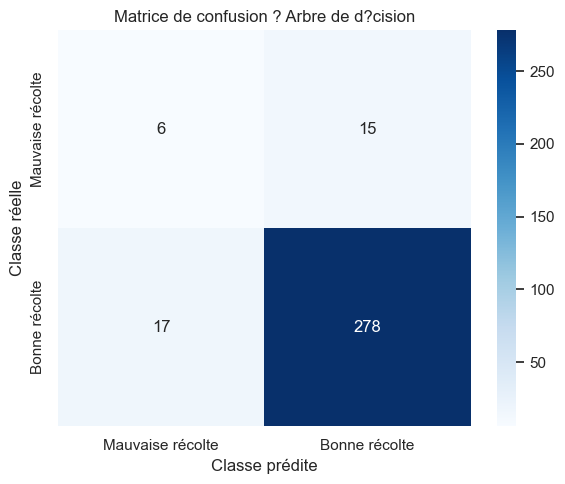

Matrice de confusion [[TN, FP], [FN, TP]]:
[[  6  15]
 [ 17 278]]
Faux positifs (classe positive = bonne r?colte): 15
Faux n?gatifs (classe positive = bonne r?colte): 17
Mauvaises r?coltes manqu?es, c.-?-d. mauvaises pr?dites bonnes: 15


In [20]:
plot_confusion_matrix(decision_tree, X_test_scaled, y_test, "Matrice de confusion ? Arbre de d?cision")

dt_cm = dt_metrics['confusion_matrix']
tn, fp, fn, tp = dt_cm.ravel()
print("Matrice de confusion [[TN, FP], [FN, TP]]:")
print(dt_cm)
print(f"Faux positifs (classe positive = bonne r?colte): {fp}")
print(f"Faux n?gatifs (classe positive = bonne r?colte): {fn}")
print(f"Mauvaises r?coltes manqu?es, c.-?-d. mauvaises pr?dites bonnes: {fp}")


Avec la convention scikit-learn o? la classe positive est `1` (bonne r?colte), l'arbre produit **15 faux positifs** et **17 faux n?gatifs**. Agronomiquement, l'erreur la plus co?teuse est surtout de pr?dire une bonne r?colte alors que la r?colte sera mauvaise : l'agriculteur ne re?oit pas d'alerte et peut ne pas prendre de mesures pr?ventives. Dans cette matrice, cela correspond aux **15 mauvaises r?coltes pr?dites bonnes**.


### Q15 ? Visualisation de l'arbre

On affiche la structure de l'arbre et on identifie la variable utilis?e ? la racine.


Variable du premier split: pluviometrie_mm
Seuil normalis? du premier split: -0.9650


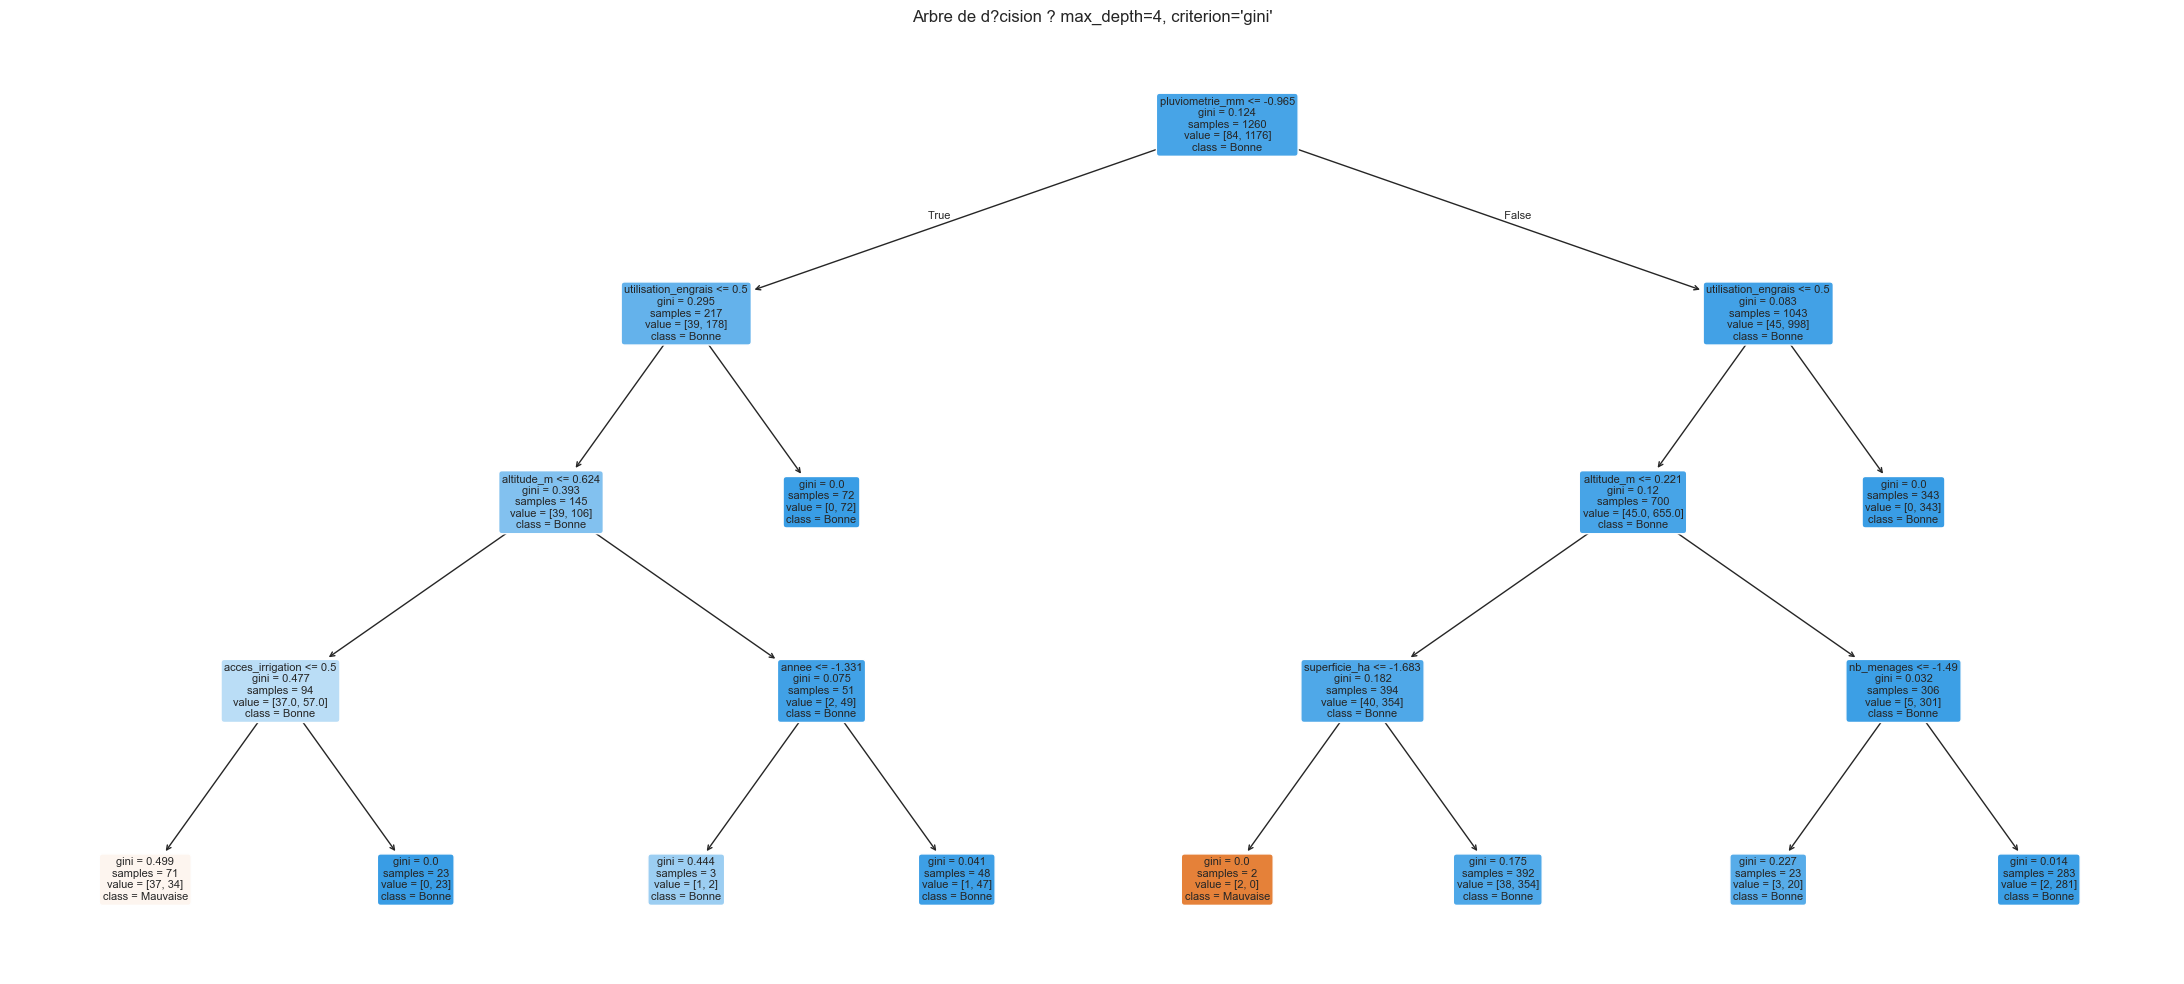

In [21]:
root_feature_index = decision_tree.tree_.feature[0]
root_feature = X_train_scaled.columns[root_feature_index]
root_threshold = decision_tree.tree_.threshold[0]

print(f"Variable du premier split: {root_feature}")
print(f"Seuil normalis? du premier split: {root_threshold:.4f}")

plt.figure(figsize=(22, 10))
plot_tree(
    decision_tree,
    feature_names=X_train_scaled.columns,
    class_names=['Mauvaise', 'Bonne'],
    filled=True,
    rounded=True,
    fontsize=8,
)
plt.title("Arbre de d?cision ? max_depth=4, criterion='gini'")
plt.tight_layout()
plt.show()


La premi?re s?paration se fait sur **`pluviometrie_mm`** avec un seuil normalis? d'environ **-0,965**. Comme la variable a ?t? standardis?e, ce seuil signifie une pluviom?trie nettement inf?rieure ? la moyenne du jeu d'entra?nement. Agronomiquement, c'est coh?rent : l'eau disponible pendant la saison est un facteur d?terminant pour la croissance des cultures et la probabilit? d'une bonne r?colte.


### Q16 ? Importance des variables de l'arbre

On affiche les variables les plus importantes pour l'arbre de d?cision.


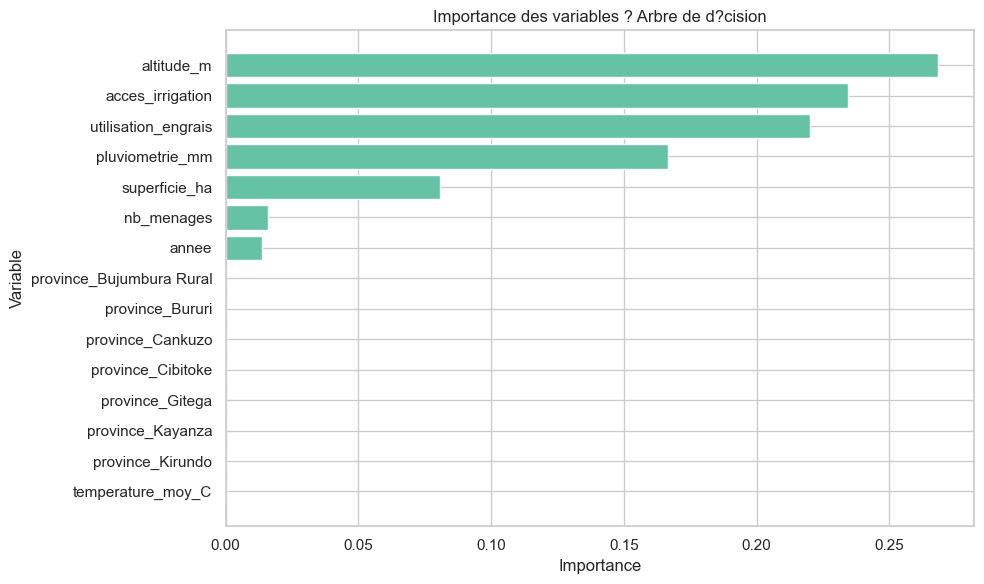

Top 10 variables ? Arbre de d?cision:


altitude_m                  0.268441
acces_irrigation            0.234428
utilisation_engrais         0.220213
pluviometrie_mm             0.166496
superficie_ha               0.080634
nb_menages                  0.016086
annee                       0.013701
temperature_moy_C           0.000000
province_Bujumbura Rural    0.000000
province_Bururi             0.000000
dtype: float64

In [22]:
plot_feature_importance(
    decision_tree,
    X_train_scaled.columns.tolist(),
    "Importance des variables ? Arbre de d?cision",
    top_n=15,
)

dt_importances = pd.Series(decision_tree.feature_importances_, index=X_train_scaled.columns).sort_values(ascending=False)
print("Top 10 variables ? Arbre de d?cision:")
display(dt_importances.head(10))


Les principales variables de l'arbre sont **`altitude_m`**, **`acces_irrigation`**, **`utilisation_engrais`**, **`pluviometrie_mm`** et **`superficie_ha`**. Ce classement est coh?rent avec l'intuition agronomique : altitude, eau et fertilisation influencent directement le rendement. L'importance de `utilisation_engrais` envoie un message clair aux d?cideurs : l'acc?s aux intrants agricoles peut ?tre un levier concret pour am?liorer les r?coltes.


### Q17 ? Analyse du surapprentissage

On entra?ne des arbres de profondeur 1 ? 20 et on compare l'accuracy train et test.


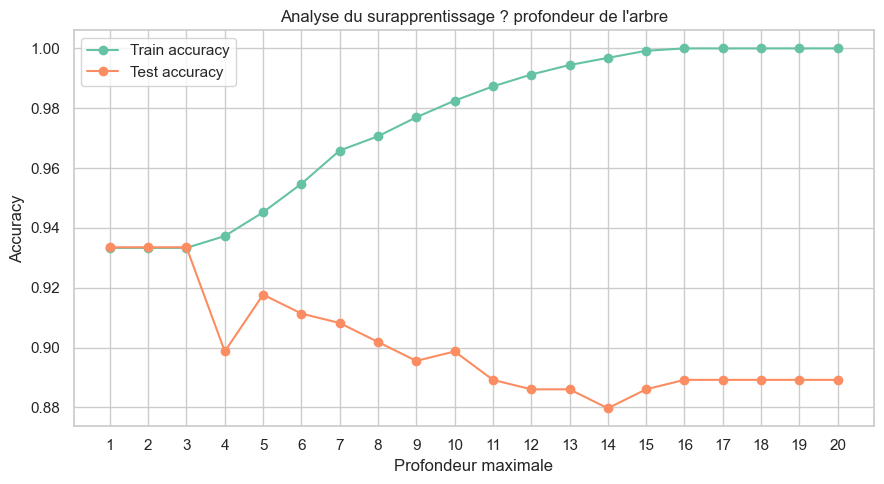

,depths,train_scores,test_scores
0,1,0.933333,0.933544
1,2,0.933333,0.933544
2,3,0.933333,0.933544
3,4,0.937302,0.898734
4,5,0.945238,0.917722
5,6,0.954762,0.911392
6,7,0.965873,0.908228
7,8,0.970635,0.901899
8,9,0.976984,0.895570
9,10,0.982540,0.898734


Meilleure profondeur selon le test: 1
Meilleure accuracy test: 0.9335


In [23]:
overfit_results = overfitting_analysis(X_train_scaled, y_train, X_test_scaled, y_test, max_depths=range(1, 21))

plt.figure(figsize=(9, 5))
plt.plot(overfit_results['depths'], overfit_results['train_scores'], marker='o', label='Train accuracy')
plt.plot(overfit_results['depths'], overfit_results['test_scores'], marker='o', label='Test accuracy')
plt.title("Analyse du surapprentissage ? profondeur de l'arbre")
plt.xlabel("Profondeur maximale")
plt.ylabel("Accuracy")
plt.xticks(overfit_results['depths'])
plt.legend()
plt.tight_layout()
plt.show()

overfit_df = pd.DataFrame(overfit_results)
display(overfit_df)

best_depth = overfit_df.loc[overfit_df['test_scores'].idxmax(), 'depths']
best_test_score = overfit_df['test_scores'].max()
print(f"Meilleure profondeur selon le test: {best_depth}")
print(f"Meilleure accuracy test: {best_test_score:.4f}")


Dans cette ex?cution, la meilleure accuracy test est obtenue avec une profondeur tr?s faible, **1** ? **3** donnant environ **0,934**. ? partir de la profondeur **4**, l'accuracy train augmente alors que l'accuracy test baisse : le surapprentissage commence donc clairement autour de **max_depth=4**. Dans un contexte agricole, cela signifie que l'arbre apprend des particularit?s historiques du dataset plut?t que des r?gles g?n?rales valables pour de nouvelles saisons ou provinces.


## Exercice 4 ? For?t Al?atoire : robustesse et comparaison

On entra?ne une for?t al?atoire de 100 arbres, on la compare ? l'arbre de d?cision, puis on ?tudie sa stabilit? par validation crois?e et par variation du nombre d'arbres.


### Q18 ? Entra?nement de la for?t al?atoire

On entra?ne une for?t al?atoire avec `n_estimators=100` et on compare son accuracy ? celle de l'arbre.


In [24]:
random_forest = train_random_forest(X_train_scaled, y_train, n_estimators=100, random_state=42)
rf_metrics = get_metrics(random_forest, X_test_scaled, y_test)

accuracy_diff = rf_metrics['accuracy'] - dt_metrics['accuracy']
print(f"Decision Tree accuracy: {dt_metrics['accuracy']:.4f}")
print(f"Random Forest accuracy: {rf_metrics['accuracy']:.4f}")
print(f"Diff?rence Random Forest - Decision Tree: {accuracy_diff:.4f}")


Decision Tree accuracy: 0.8987
Random Forest accuracy: 0.9304
Diff?rence Random Forest - Decision Tree: 0.0316


La for?t al?atoire obtient une accuracy d'environ **0,930**, contre **0,899** pour l'arbre de profondeur 4. Elle est donc meilleure d'environ **3,16 points de pourcentage** sur ce jeu de test. Cette am?lioration vient du fait qu'elle agr?ge plusieurs arbres au lieu de d?pendre d'une seule structure de d?cision.


### Q19 ? Pourquoi une for?t peut mieux g?n?raliser


In [25]:
print("Une for?t al?atoire combine plusieurs arbres entra?n?s sur des ?chantillons bootstrap.")


Une for?t al?atoire combine plusieurs arbres entra?n?s sur des ?chantillons bootstrap.


Le **bagging** consiste ? entra?ner plusieurs arbres sur des ?chantillons tir?s avec remise, puis ? agr?ger leurs pr?dictions. Cela r?duit la variance par rapport ? un arbre unique. Le param?tre `max_features` force chaque split ? ne consid?rer qu'une partie des variables, ce qui rend les arbres moins corr?l?s entre eux. Une for?t al?atoire peut tout de m?me surapprendre, surtout si les arbres sont tr?s profonds, si le dataset est petit ou si les variables contiennent du bruit et des fuites d'information.


### Q20 ? Validation crois?e ? 5 folds

On ?value la for?t al?atoire avec une validation crois?e ? 5 folds.


In [26]:
rf_cv = cross_validate_model(
    RandomForestClassifier(n_estimators=100, random_state=42),
    X_train_scaled,
    y_train,
    cv=5,
)

print("Scores CV:", rf_cv['all_scores'])
print(f"Accuracy CV moyenne ? ?cart-type: {rf_cv['mean_accuracy']:.4f} ? {rf_cv['std_accuracy']:.4f}")
print(f"Accuracy test simple: {rf_metrics['accuracy']:.4f}")


Scores CV: [0.92857143 0.93650794 0.93253968 0.93253968 0.94047619]
Accuracy CV moyenne ? ?cart-type: 0.9341 ? 0.0040
Accuracy test simple: 0.9304


La validation crois?e donne une accuracy moyenne d'environ **0,934 ? 0,004**, tr?s proche de l'accuracy simple du test (**0,930**). La validation crois?e est plus fiable qu'un seul split, car elle ?value le mod?le sur plusieurs d?coupages des donn?es et r?duit le risque de conclure ? partir d'un jeu de test particuli?rement favorable ou d?favorable.


### Q21 ? Importance des variables de la for?t al?atoire

On affiche les variables les plus importantes pour la for?t et on compare le top-5 avec celui de l'arbre.


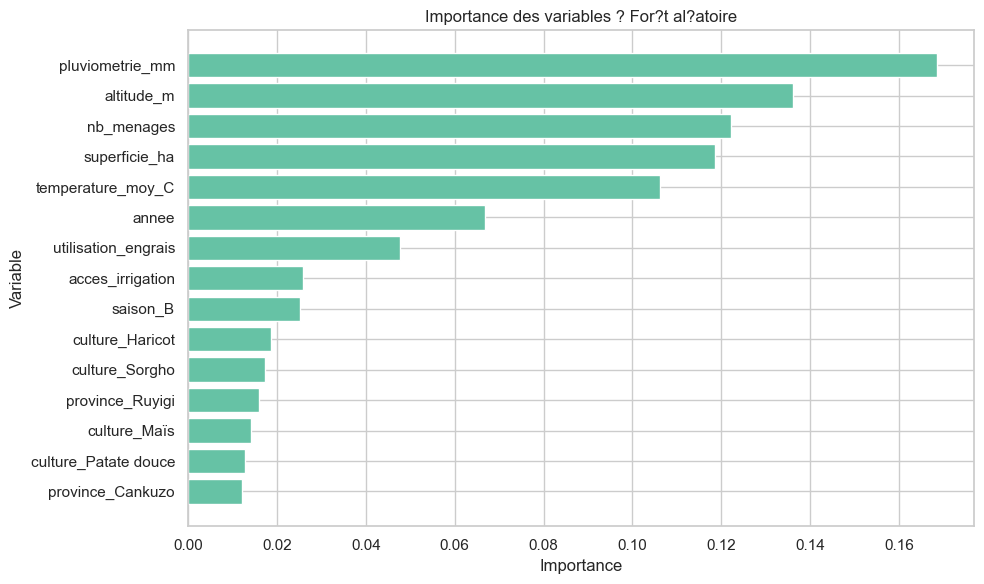

Top 5 arbre de d?cision:


altitude_m             0.268441
acces_irrigation       0.234428
utilisation_engrais    0.220213
pluviometrie_mm        0.166496
superficie_ha          0.080634
dtype: float64

Top 5 for?t al?atoire:


pluviometrie_mm      0.168494
altitude_m           0.136179
nb_menages           0.122259
superficie_ha        0.118666
temperature_moy_C    0.106247
dtype: float64

In [27]:
plot_feature_importance(
    random_forest,
    X_train_scaled.columns.tolist(),
    "Importance des variables ? For?t al?atoire",
    top_n=15,
)

rf_importances = pd.Series(random_forest.feature_importances_, index=X_train_scaled.columns).sort_values(ascending=False)
print("Top 5 arbre de d?cision:")
display(dt_importances.head(5))
print("Top 5 for?t al?atoire:")
display(rf_importances.head(5))


Le top-5 de la for?t met surtout en avant **`pluviometrie_mm`**, **`altitude_m`**, **`nb_menages`**, **`superficie_ha`** et **`temperature_moy_C`**. Il partage avec l'arbre l'importance de l'altitude, de la pluie et de la superficie, mais il r?partit davantage l'importance entre plusieurs variables continues. C'est attendu : la for?t moyenne de nombreux arbres et donne souvent une vision moins d?pendante d'un seul chemin de d?cision.


### Q22 ? Impact du nombre d'arbres

On fait varier `n_estimators` de 10 ? 500 par pas de 10 et on observe l'accuracy test.


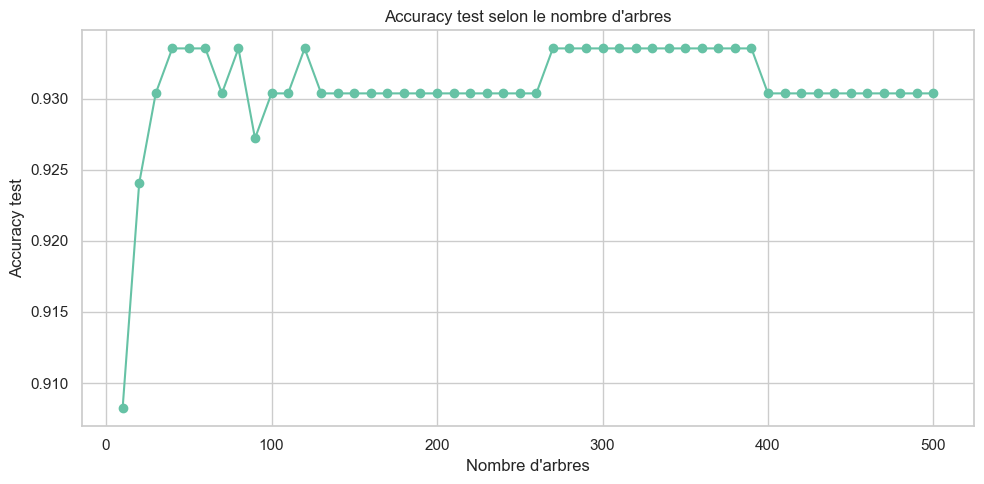

,n_estimators,test_accuracy
0,10,0.908228
1,20,0.924051
2,30,0.930380
3,40,0.933544
4,50,0.933544
5,60,0.933544
6,70,0.930380
7,80,0.933544
8,90,0.927215
9,100,0.930380


Meilleur r?sultat:


n_estimators     40.000000
test_accuracy     0.933544
Name: 3, dtype: float64

In [28]:
n_estimators_values = list(range(10, 501, 10))
rf_estimator_scores = []

for n_estimators in n_estimators_values:
    model = RandomForestClassifier(n_estimators=n_estimators, random_state=42)
    model.fit(X_train_scaled, y_train)
    rf_estimator_scores.append(model.score(X_test_scaled, y_test))

plt.figure(figsize=(10, 5))
plt.plot(n_estimators_values, rf_estimator_scores, marker='o')
plt.title("Accuracy test selon le nombre d'arbres")
plt.xlabel("Nombre d'arbres")
plt.ylabel("Accuracy test")
plt.tight_layout()
plt.show()

rf_estimators_df = pd.DataFrame({'n_estimators': n_estimators_values, 'test_accuracy': rf_estimator_scores})
display(rf_estimators_df)
print("Meilleur r?sultat:")
display(rf_estimators_df.loc[rf_estimators_df['test_accuracy'].idxmax()])


La performance se stabilise rapidement autour de **40 ? 100 arbres**, puis reste tr?s proche de **0,930** jusqu'? 500 arbres. Ajouter plus d'arbres rend le mod?le plus co?teux ? entra?ner et ? charger, mais n'apporte presque plus de gain mesurable ici. Un compromis raisonnable est donc de garder **100 arbres**, comme demand? dans l'exercice.


## Exercice 5 ? R?gression Logistique : interpr?tation et courbes ROC

On entra?ne une r?gression logistique, on interpr?te ses coefficients, puis on compare les trois mod?les avec accuracy, F1 et AUC.


### Q23 ? Entra?nement et coefficients de la r?gression logistique

On entra?ne la r?gression logistique et on affiche les coefficients les plus positifs et les plus n?gatifs.


In [29]:
logistic_regression = train_logistic_regression(X_train_scaled, y_train, max_iter=1000, random_state=42)
lr_metrics = get_metrics(logistic_regression, X_test_scaled, y_test)

lr_coefficients = pd.Series(logistic_regression.coef_[0], index=X_train_scaled.columns).sort_values(ascending=False)
print(f"Logistic Regression accuracy: {lr_metrics['accuracy']:.4f}")
print("Coefficients les plus positifs:")
display(lr_coefficients.head(10))
print("Coefficients les plus n?gatifs:")
display(lr_coefficients.tail(10))


Logistic Regression accuracy: 0.9399
Coefficients les plus positifs:


utilisation_engrais         2.972350
acces_irrigation            2.587341
province_Gitega             1.097343
pluviometrie_mm             0.924012
altitude_m                  0.619222
province_Kayanza            0.560465
province_Bururi             0.534917
province_Cibitoke           0.417850
province_Bujumbura Rural    0.299211
superficie_ha               0.262699
dtype: float64

Coefficients les plus n?gatifs:


temperature_moy_C   -0.192108
province_Muyinga    -0.254616
culture_Haricot     -0.259522
culture_Maïs        -0.368789
province_Kirundo    -0.388930
culture_Sorgho      -0.457688
saison_B            -0.461942
province_Ngozi      -0.508169
province_Cankuzo    -0.790578
province_Ruyigi     -0.822704
dtype: float64

Les coefficients positifs les plus forts sont **`utilisation_engrais`**, **`acces_irrigation`**, **`province_Gitega`**, **`pluviometrie_mm`** et **`altitude_m`**. Ils indiquent que ces facteurs augmentent la probabilit? estim?e d'une bonne r?colte. Les coefficients n?gatifs incluent notamment **`province_Ruyigi`**, **`province_Cankuzo`**, **`province_Ngozi`**, **`saison_B`** et certaines cultures comme **sorgho** ou **ma?s** dans ce codage. Ces effets sont plausibles comme associations statistiques, mais ils doivent ?tre interpr?t?s avec prudence : les coefficients des variables One-Hot sont relatifs aux cat?gories de r?f?rence supprim?es par `drop_first=True`.


### Q24 ? Comparaison des accuracies

On compare la r?gression logistique avec l'arbre de d?cision et la for?t al?atoire.


In [30]:
accuracy_comparison = pd.DataFrame({
    'model': ['Decision Tree', 'Random Forest', 'Logistic Regression'],
    'accuracy': [dt_metrics['accuracy'], rf_metrics['accuracy'], lr_metrics['accuracy']],
    'f1_weighted': [dt_metrics['f1'], rf_metrics['f1'], lr_metrics['f1']],
})
display(accuracy_comparison.sort_values('accuracy', ascending=False))


,model,accuracy,f1_weighted
2,Logistic Regression,0.939873,0.920272
1,Random Forest,0.930380,0.899875
0,Decision Tree,0.898734,0.900863


Dans cette ex?cution, la r?gression logistique obtient la meilleure accuracy, environ **0,940**, devant la for?t al?atoire (**0,930**) et l'arbre de d?cision (**0,899**). L'hypoth?se de lin?arit? est une simplification forte pour des donn?es agricoles, car les effets de la pluie, de la temp?rature et de l'altitude peuvent ?tre non lin?aires. Cependant, sur ce dataset pr?cis, les variables disponibles semblent contenir un signal assez bien captur? par une fronti?re lin?aire.


### Q25 ? Courbes ROC et AUC

On trace les courbes ROC des trois mod?les et on calcule l'AUC de chacun.


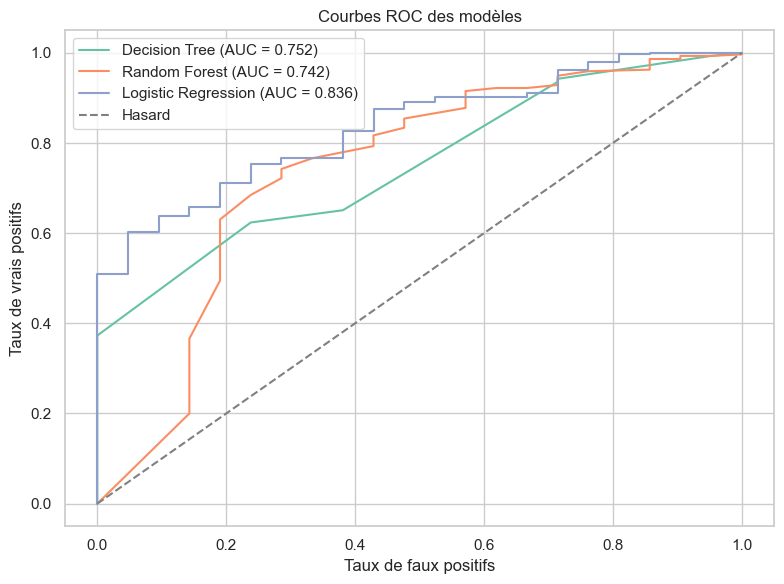

AUC par mod?le:
{'Decision Tree': 0.7519774011299435, 'Random Forest': 0.7418886198547217, 'Logistic Regression': 0.8358353510895884}


In [31]:
models_for_roc = {
    'Decision Tree': decision_tree,
    'Random Forest': random_forest,
    'Logistic Regression': logistic_regression,
}
auc_scores = plot_roc_curves(models_for_roc, X_test_scaled, y_test)
print("AUC par mod?le:")
print(auc_scores)


La meilleure AUC est obtenue par la **r?gression logistique** avec environ **0,836**. L'arbre de d?cision obtient environ **0,752**, et la for?t al?atoire environ **0,742**. Le classement par AUC correspond ici globalement au classement par accuracy pour le meilleur mod?le, mais il nuance la for?t : malgr? une bonne accuracy, son AUC reste plus faible, ce qui indique une capacit? moins bonne ? classer les observations selon leur risque r?el sur tous les seuils.


### Q26 ? Interpr?tation de l'AUC


In [32]:
print("AUC scores:")
for model_name, score in auc_scores.items():
    print(f"{model_name}: {score:.4f}")


AUC scores:
Decision Tree: 0.7520
Random Forest: 0.7419
Logistic Regression: 0.8358


L'AUC mesure la capacit? d'un mod?le ? classer une observation positive au-dessus d'une observation n?gative sur l'ensemble des seuils possibles. Elle est plus informative que l'accuracy lorsque les classes sont d?s?quilibr?es, car l'accuracy peut ?tre ?lev?e simplement en pr?disant souvent la classe majoritaire. Oui, un mod?le peut avoir **75 % d'accuracy** et une **AUC proche de 0,5** s'il pr?dit surtout la classe dominante mais ne discrimine pas r?ellement les risques. Pour la pr?diction agricole, il faut regarder les deux, mais l'AUC et le rappel des mauvaises r?coltes sont particuli?rement importants : manquer une mauvaise r?colte peut co?ter plus cher qu'une alerte prudente.


## Sauvegarde des mod?les et r?sum? final

On sauvegarde les trois mod?les, le scaler, les colonnes de features, puis `metrics.json`. On termine par un tableau comparatif.


In [33]:
trained_models = train_and_save_all(X_train_scaled, y_train, scaler, feature_columns)

compact_metrics = {
    'decision_tree': {
        'accuracy': dt_metrics['accuracy'],
        'f1': dt_metrics['f1'],
        'auc': auc_scores['Decision Tree'],
    },
    'random_forest': {
        'accuracy': rf_metrics['accuracy'],
        'f1': rf_metrics['f1'],
        'auc': auc_scores['Random Forest'],
    },
    'logistic_regression': {
        'accuracy': lr_metrics['accuracy'],
        'f1': lr_metrics['f1'],
        'auc': auc_scores['Logistic Regression'],
    },
}
save_metrics(compact_metrics, path='metrics.json')

summary_table = pd.DataFrame([
    {
        'model': 'Decision Tree',
        'accuracy': dt_metrics['accuracy'],
        'f1_weighted': dt_metrics['f1'],
        'auc': auc_scores['Decision Tree'],
        'cv_mean': np.nan,
        'cv_std': np.nan,
    },
    {
        'model': 'Random Forest',
        'accuracy': rf_metrics['accuracy'],
        'f1_weighted': rf_metrics['f1'],
        'auc': auc_scores['Random Forest'],
        'cv_mean': rf_cv['mean_accuracy'],
        'cv_std': rf_cv['std_accuracy'],
    },
    {
        'model': 'Logistic Regression',
        'accuracy': lr_metrics['accuracy'],
        'f1_weighted': lr_metrics['f1'],
        'auc': auc_scores['Logistic Regression'],
        'cv_mean': np.nan,
        'cv_std': np.nan,
    },
])

display(summary_table)
print("metrics.json sauvegard? ? la racine du projet.")
print("Mod?les sauvegard?s dans models/: decision_tree.pkl, random_forest.pkl, logistic_regression.pkl")
print("Artifacts sauvegard?s: scaler.pkl, feature_columns.pkl")


,model,accuracy,f1_weighted,auc,cv_mean,cv_std
0,Decision Tree,0.898734,0.900863,0.751977,NaN,NaN
1,Random Forest,0.930380,0.899875,0.741889,0.934127,0.004047
2,Logistic Regression,0.939873,0.920272,0.835835,NaN,NaN


metrics.json sauvegard? ? la racine du projet.
Mod?les sauvegard?s dans models/: decision_tree.pkl, random_forest.pkl, logistic_regression.pkl
Artifacts sauvegard?s: scaler.pkl, feature_columns.pkl


## Exercice 6 ? Pr?diction sur de nouvelles donn?es r?elles

Cette section utilise les mod?les d?j? sauvegard?s dans `models/` pour simuler des pr?dictions sur quatre sc?narios agricoles. Aucun mod?le n'est r?entra?n? : on recharge le scaler, la liste des colonnes et les trois mod?les sauvegard?s.


### Q27 ? Pr?dictions des quatre sc?narios

Les sc?narios fournis ne contiennent pas `annee`, `saison`, `superficie_ha` et `nb_menages`, alors que ces variables font partie des features d'entra?nement. Pour garder une inf?rence reproductible sans r?entra?ner les mod?les, on utilise l'ann?e maximale du dataset, la saison A, puis la m?diane observ?e pour `superficie_ha` et `nb_menages` dans le couple province-culture concern?. Ensuite, la transformation passe par `build_inference_input()` afin de respecter exactement les colonnes d'entra?nement.


In [34]:
import joblib

from src.preprocess import build_inference_input

loaded_models = {
    'DT': joblib.load(PROJECT_ROOT / 'models' / 'decision_tree.pkl'),
    'RF': joblib.load(PROJECT_ROOT / 'models' / 'random_forest.pkl'),
    'LR': joblib.load(PROJECT_ROOT / 'models' / 'logistic_regression.pkl'),
}
loaded_scaler = joblib.load(PROJECT_ROOT / 'models' / 'scaler.pkl')
loaded_feature_columns = joblib.load(PROJECT_ROOT / 'models' / 'feature_columns.pkl')
loaded_numerical_cols = list(loaded_scaler.feature_names_in_)

maize_dataset_value = [
    culture for culture in df_clean['culture'].unique()
    if str(culture).startswith('Ma') and culture != 'Manioc'
][0]


def canonicalize_culture(culture):
    # Align user-facing culture names with the exact dataset encoding.
    if culture in df_clean['culture'].unique():
        return culture
    if str(culture).startswith('Ma') and culture != 'Manioc':
        return maize_dataset_value
    return culture


def add_missing_scenario_defaults(raw_scenario):
    # Add reproducible defaults for features omitted from the scenario table.
    scenario = raw_scenario.copy()
    scenario['culture'] = canonicalize_culture(scenario['culture'])
    group = df_clean[
        (df_clean['province'] == scenario['province'])
        & (df_clean['culture'] == scenario['culture'])
    ]
    reference = group if not group.empty else df_clean
    scenario['annee'] = int(df_clean['annee'].max())
    scenario['saison'] = 'A'
    scenario['superficie_ha'] = float(reference['superficie_ha'].median())
    scenario['nb_menages'] = int(round(reference['nb_menages'].median()))
    return scenario


def predict_scenario(raw_scenario):
    # Predict one scenario with all saved models using saved preprocessing artifacts.
    scenario = {
        'province': raw_scenario['province'],
        'culture': raw_scenario['culture'],
        'altitude_m': raw_scenario['altitude_m'],
        'pluviometrie_mm': raw_scenario['pluviometrie_mm'],
        'temperature_moy_C': raw_scenario['temperature_moy_C'],
        'utilisation_engrais': 1 if raw_scenario['utilisation_engrais'] == 'Oui' else 0,
        'acces_irrigation': 1 if raw_scenario['acces_irrigation'] == 'Oui' else 0,
    }
    scenario = add_missing_scenario_defaults(scenario)
    X_inference = build_inference_input(
        scenario,
        loaded_feature_columns,
        loaded_scaler,
        loaded_numerical_cols,
    )

    predictions = {}
    for model_name, model in loaded_models.items():
        pred_class = int(model.predict(X_inference)[0])
        pred_proba = model.predict_proba(X_inference)[0]
        label = 'Bonne' if pred_class == 1 else 'Mauvaise'
        probability = float(pred_proba[pred_class])
        predictions[model_name] = {'prediction': label, 'probability': probability}

    return predictions


scenarios = [
    {
        'Scenario': 'Kayanza - Ma?s',
        'province': 'Kayanza',
        'culture': 'Maïs',
        'altitude_m': 1980,
        'pluviometrie_mm': 920,
        'temperature_moy_C': 17.8,
        'utilisation_engrais': 'Oui',
        'acces_irrigation': 'Non',
    },
    {
        'Scenario': 'Bubanza - Manioc',
        'province': 'Bubanza',
        'culture': 'Manioc',
        'altitude_m': 790,
        'pluviometrie_mm': 550,
        'temperature_moy_C': 25.4,
        'utilisation_engrais': 'Non',
        'acces_irrigation': 'Oui',
    },
    {
        'Scenario': 'Gitega - Haricot',
        'province': 'Gitega',
        'culture': 'Haricot',
        'altitude_m': 1720,
        'pluviometrie_mm': 430,
        'temperature_moy_C': 18.2,
        'utilisation_engrais': 'Non',
        'acces_irrigation': 'Non',
    },
    {
        'Scenario': 'Cibitoke - Patate douce',
        'province': 'Cibitoke',
        'culture': 'Patate douce',
        'altitude_m': 810,
        'pluviometrie_mm': 810,
        'temperature_moy_C': 24.1,
        'utilisation_engrais': 'Oui',
        'acces_irrigation': 'Oui',
    },
]

scenario_rows = []
scenario_detail_rows = []
for scenario in scenarios:
    predictions = predict_scenario(scenario)
    row = {'Scenario': scenario['Scenario']}
    for model_key, display_name in [('DT', 'DT (pred, prob%)'), ('RF', 'RF (pred, prob%)'), ('LR', 'LR (pred, prob%)')]:
        pred = predictions[model_key]['prediction']
        prob = predictions[model_key]['probability'] * 100
        row[display_name] = f'{pred} ({prob:.1f} %)'
        scenario_detail_rows.append({
            'Scenario': scenario['Scenario'],
            'Mod?le': model_key,
            'Pr?diction': pred,
            'Probabilit?': prob,
            'Distance ? 50%': abs(prob - 50),
        })
    scenario_rows.append(row)

scenario_predictions_df = pd.DataFrame(scenario_rows)
scenario_details_df = pd.DataFrame(scenario_detail_rows)
display(scenario_predictions_df)


,Scenario,"DT (pred, prob%)","RF (pred, prob%)","LR (pred, prob%)"
0,Kayanza - Ma?s,Bonne (100.0 %),Bonne (100.0 %),Bonne (100.0 %)
1,Bubanza - Manioc,Bonne (100.0 %),Bonne (87.0 %),Bonne (95.3 %)
2,Gitega - Haricot,Bonne (97.9 %),Bonne (86.0 %),Bonne (90.0 %)
3,Cibitoke - Patate douce,Bonne (100.0 %),Bonne (97.0 %),Bonne (100.0 %)


Les quatre sc?narios sont pr?dits comme **bonne r?colte** par les trois mod?les. Les probabilit?s associ?es sont tr?s ?lev?es pour les sc?narios 1 et 4, tandis que les sc?narios 2 et surtout 3 pr?sentent des probabilit?s un peu plus faibles selon la for?t al?atoire et la r?gression logistique.


### Q28 ? Accord des mod?les et incertitude

On v?rifie l'accord entre mod?les et on cherche la pr?diction la plus proche de 50 %, c'est-?-dire celle qui traduit la plus grande incertitude relative.


In [35]:
agreement = scenario_details_df.groupby('Scenario')['Pr?diction'].nunique().reset_index(name='Nombre de pr?dictions distinctes')
most_uncertain = scenario_details_df.loc[scenario_details_df['Distance ? 50%'].idxmin()]

display(agreement)
print("Pr?diction la plus proche de 50%:")
display(most_uncertain)


,Scenario,Nombre de pr?dictions distinctes
0,Bubanza - Manioc,1
1,Cibitoke - Patate douce,1
2,Gitega - Haricot,1
3,Kayanza - Ma?s,1


Pr?diction la plus proche de 50%:


Scenario          Gitega - Haricot
Mod?le                          RF
Pr?diction                   Bonne
Probabilit?                   86.0
Distance ? 50%                36.0
Name: 7, dtype: object

Les trois mod?les sont **unanimes pour les quatre sc?narios** : ils pr?disent tous une bonne r?colte. Il n'y a donc pas de d?saccord direct dans cette simulation. Le sc?nario qui pr?sente le plus d'incertitude est **Gitega - Haricot**, car la for?t al?atoire donne une probabilit? de bonne r?colte d'environ **86,0 %**, la plus proche de 50 % parmi les pr?dictions. Cette incertitude relative est coh?rente avec la faible pluviom?trie de 430 mm et l'absence d'engrais et d'irrigation. Lorsque les mod?les ne sont pas d'accord, un d?cideur ne devrait pas choisir m?caniquement la pr?diction la plus optimiste : il devrait regarder les probabilit?s, les m?triques globales des mod?les, le co?t des erreurs et, si possible, demander une v?rification agronomique locale avant de formuler une recommandation.
